# Damped Harmonic Oscillator — Physics-Informed Neural Network (Forward Problem)

This notebook implements a forward Physics-Informed Neural Network (PINN) to solve the
damped harmonic oscillator equation:

$$ m\ddot{x} + c\dot{x} + kx = 0, \quad x(0) = x_0, \quad \dot{x}(0) = v_0 $$

Instead of using a classical numerical integrator (as in `Oscillator.ipynb`), a neural
network is trained to approximate `x(t)` directly, using the ODE residual and initial
conditions as the training signal — no labeled trajectory data is required for the base
approach.

**Parameters used:**
* $m = 1.0$ kg
* $c = 0.5$
* $k = 2.0$ N/m
* $x_0 = 1.0$ m
* $v_0 = 0.0$ m/s

The network's output is validated against the classical `odeint` solution from
`Oscillator.ipynb` for the same parameters.

## Methodology

- A fully connected neural network (`MotionPredictor`) takes time `t` as input and
  predicts position `x(t)` as output.
- Collocation points are sampled across the simulation domain (`t ∈ [0, 20]`, 500 points),
  used to enforce the ODE via automatic differentiation (`torch.autograd.grad`), computing
  `dx/dt` and `d²x/dt²` directly from the network's output.
- The training loss combines three terms:
  1. **Physics loss** — mean squared ODE residual across all collocation points.
  2. **Initial condition loss** — squared error between the network's predicted
     position/velocity at `t = 0` and the true `x0`, `v0`.
  3. **Data loss** — squared error against the classical solution at a small set of
     sparse anchor points (added to address a specific failure mode, described below).

In [7]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

In [8]:
# The function for relation between the different equations

def msd_system(state, t, m, c, k):
    dxdt = state[1]
    dvdt = (-c * state[1] - k * state[0]) / m
    return [dxdt, dvdt]

In [9]:
torch.manual_seed(42)
# Default parameters
m0 = 1.0  # Mass (kg)
c0 = 0.5  # Damping coefficient (N·s/m)
k0 = 2.0  # Spring constant (N/m)

# Default initial conditions
time_array = np.linspace(0, 20, 500)  # Time from 0 to 20 seconds
x0, v0 = (1.0, 0.0)  # Initial position and velocity
initial_state = [x0, v0]

print("Given initial conditions:")
print(f"---> Initial position (x0): {x0}")
print(f"---> Initial velocity (v0): {v0}\n")
print("Given system parameters:")
print(f"---> Mass (m): {m0}")
print(f"---> Damping coefficient (c): {c0}")
print(f"---> Spring constant (k): {k0}\n")
solution = odeint(msd_system, initial_state, time_array, args=(m0, c0, k0))
x_all = torch.from_numpy(solution.T[0]).to(torch.float32).unsqueeze(dim=1)  # Position over time
v_all = torch.from_numpy(solution.T[1]).to(torch.float32).unsqueeze(dim=1)  # Velocity over time

time_array=torch.from_numpy(time_array).to(torch.float32).unsqueeze(dim=1)
time_array.requires_grad_(True)


Given initial conditions:
---> Initial position (x0): 1.0
---> Initial velocity (v0): 0.0

Given system parameters:
---> Mass (m): 1.0
---> Damping coefficient (c): 0.5
---> Spring constant (k): 2.0



tensor([[ 0.0000],
        [ 0.0401],
        [ 0.0802],
        [ 0.1202],
        [ 0.1603],
        [ 0.2004],
        [ 0.2405],
        [ 0.2806],
        [ 0.3206],
        [ 0.3607],
        [ 0.4008],
        [ 0.4409],
        [ 0.4810],
        [ 0.5210],
        [ 0.5611],
        [ 0.6012],
        [ 0.6413],
        [ 0.6814],
        [ 0.7214],
        [ 0.7615],
        [ 0.8016],
        [ 0.8417],
        [ 0.8818],
        [ 0.9218],
        [ 0.9619],
        [ 1.0020],
        [ 1.0421],
        [ 1.0822],
        [ 1.1222],
        [ 1.1623],
        [ 1.2024],
        [ 1.2425],
        [ 1.2826],
        [ 1.3226],
        [ 1.3627],
        [ 1.4028],
        [ 1.4429],
        [ 1.4830],
        [ 1.5230],
        [ 1.5631],
        [ 1.6032],
        [ 1.6433],
        [ 1.6834],
        [ 1.7234],
        [ 1.7635],
        [ 1.8036],
        [ 1.8437],
        [ 1.8838],
        [ 1.9238],
        [ 1.9639],
        [ 2.0040],
        [ 2.0441],
        [ 2.

In [10]:
# Creating the neural network

class MotionPredictor(nn.Module):
  def __init__(self, *args: any, **kwargs: any) -> None:
      super().__init__(*args, **kwargs)

      self.tan_h=nn.Tanh()
      self.layer1=nn.Linear(in_features=1, out_features=15)
      self.layer2=nn.Linear(in_features=15, out_features=15)
      self.layer3=nn.Linear(in_features=15, out_features=15)
      self.layer4=nn.Linear(in_features=15, out_features=1)

  def forward(self,t):
      return self.layer4(self.tan_h(self.layer3(self.tan_h(self.layer2(self.tan_h(self.layer1(t)))))))



In [11]:
model = MotionPredictor()
t_init=torch.tensor([[0.]], requires_grad=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [12]:
# Train the ML model

epochs = 32000
test_time=np.array([0,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6.5,7,8,8.5,9.5,10,10.5,11,11.5,12,12.5,13,13.5,14.5,15,17,18.5,20])
test_sol = odeint(msd_system, initial_state, test_time, args=(m0, c0, k0))
test_time=torch.from_numpy(test_time).to(torch.float32).unsqueeze(dim=1)
test_x_act = torch.from_numpy(test_sol.T[0]).to(torch.float32).unsqueeze(dim=1)  # Position over time



for epoch in range(epochs):
    optimizer.zero_grad()

    # forward pass + derivatives on your 200-point time_array
    x_estimate = model(time_array)
    v_estimate = torch.autograd.grad(x_estimate, time_array, torch.ones_like(x_estimate), create_graph=True)[0]
    a_estimate = torch.autograd.grad(v_estimate, time_array, torch.ones_like(v_estimate), create_graph=True)[0]

    physics_loss = (m0*a_estimate + c0*v_estimate + k0*x_estimate).pow(2).mean()

    # initial condition at t=0
    x_init = model(t_init)
    v_init = torch.autograd.grad(x_init, t_init, torch.ones_like(x_init), create_graph=True)[0]

    ic_loss = ((x_init - x0)**2 + (v_init - v0)**2) / 2.0
    test_x_mod = model(test_time)
    data_loss = (test_x_mod - test_x_act).pow(2).mean()

    total_loss = 3*physics_loss + 0.5*ic_loss + 10*data_loss

    total_loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print("Epoch number: ", epoch)
        print(f"Physics Value Loss: {physics_loss.item():.7f}\nInitial condition loss: {ic_loss.item():.7f}\n")
print("Training Complete!")

Epoch number:  0
Physics Value Loss: 0.3954269
Initial condition loss: 0.6247399

Epoch number:  500
Physics Value Loss: 0.0181128
Initial condition loss: 0.0086354

Epoch number:  1000
Physics Value Loss: 0.0092236
Initial condition loss: 0.0001369

Epoch number:  1500
Physics Value Loss: 0.0060520
Initial condition loss: 0.0000468

Epoch number:  2000
Physics Value Loss: 0.0067028
Initial condition loss: 0.0000930

Epoch number:  2500
Physics Value Loss: 0.0049612
Initial condition loss: 0.0000199

Epoch number:  3000
Physics Value Loss: 0.0046298
Initial condition loss: 0.0000142

Epoch number:  3500
Physics Value Loss: 0.0044864
Initial condition loss: 0.0000110

Epoch number:  4000
Physics Value Loss: 0.0041709
Initial condition loss: 0.0000098

Epoch number:  4500
Physics Value Loss: 0.0040039
Initial condition loss: 0.0000086

Epoch number:  5000
Physics Value Loss: 0.0041066
Initial condition loss: 0.0000183

Epoch number:  5500
Physics Value Loss: 0.0034834
Initial condition l

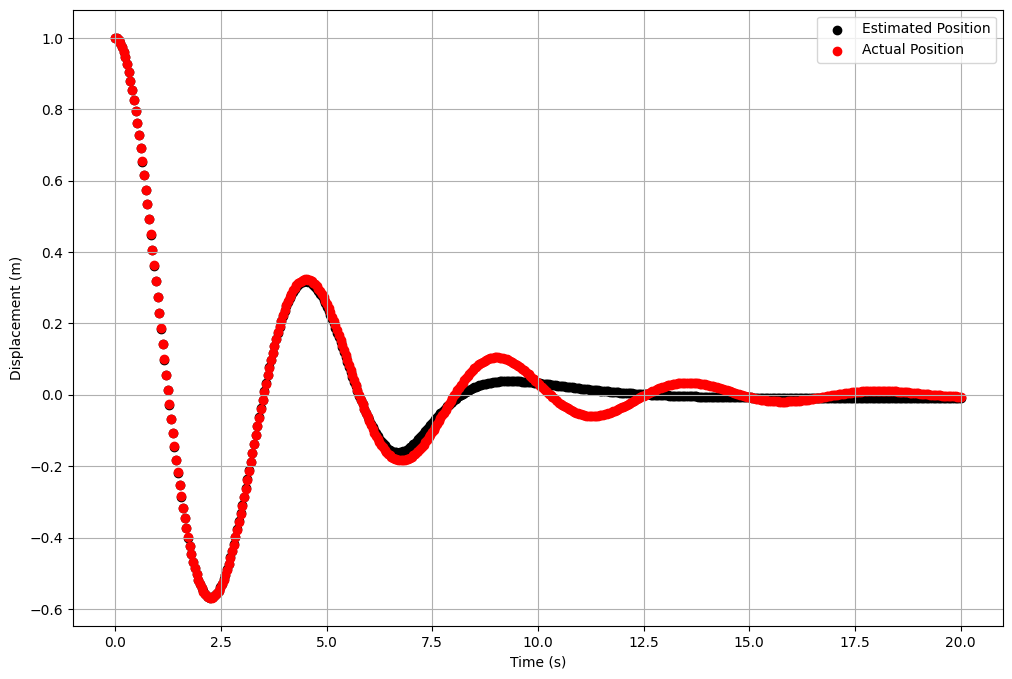

In [13]:
# Plotting estimated position vs actual position

test_time=torch.linspace(0,20,500).unsqueeze(dim=1).to(torch.float32)
with torch.inference_mode():
  test_x=model(test_time)

    
plt.figure(figsize=(12,8))
plt.subplot(1,1,1)
plt.scatter(test_time,test_x.squeeze().numpy(), c='black', label='Estimated Position')
plt.scatter(test_time,x_all,c='Red',label='Actual Position')
plt.grid()
plt.xlabel("Time (s)")
plt.ylabel('Displacement (m)')
plt.legend()


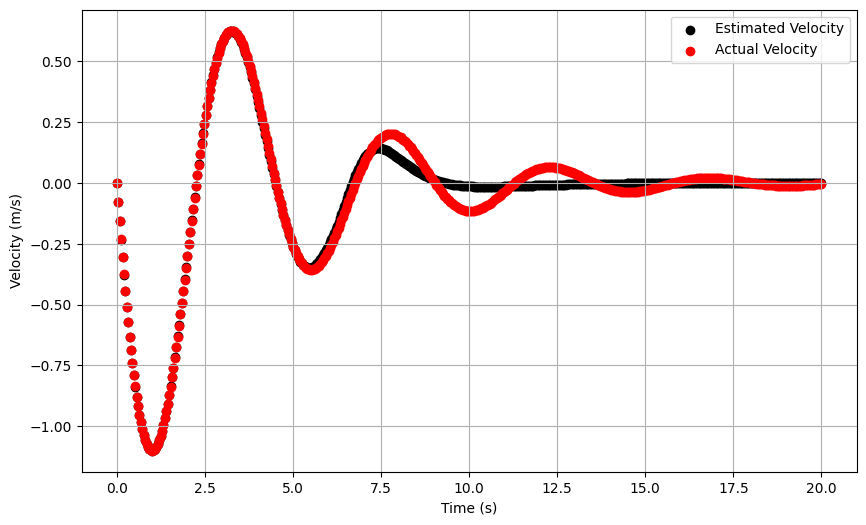

In [14]:
# Plotting estimated velocity with actual velocity

test_time.requires_grad_(True)
test_x = model(test_time)

test_v = torch.autograd.grad(outputs=test_x,inputs=test_time,grad_outputs=torch.ones_like(test_x),create_graph=False)[0]

plt.figure(figsize=(10,6))
plt.scatter(test_time.squeeze().detach().numpy(), test_v.squeeze().detach().numpy(), color='black', label='Estimated Velocity')
plt.scatter(test_time.squeeze().detach().numpy(), v_all, color='red', label='Actual Velocity') 
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel('Velocity (m/s)')
plt.grid(True)
plt.show()




In [15]:
x_net_error=(test_x-x_all).pow(2).mean()
print(f"Position MSE: {x_net_error:.7f}")

v_net_error = (test_v.detach() - v_all).pow(2).mean()
print(f"Velocity MSE: {v_net_error.item():.7f}")

Position MSE: 0.0007589
Velocity MSE: 0.0014022


## Failure Mode: Tail Flattening and the Fix

Training with only the physics loss and initial-condition loss produced a network that matched the true solution closely for early time (`t < 7`), but flattened toward zero for larger `t`, failing to track the true solution's small remaining oscillations out to `t = 20`.

**Diagnosis:** the ODE residual does not distinguish between "correctly tracking a small, decaying oscillation" and "simply being near zero." Since the true solution's amplitude decays substantially over time, a flattened output trivially produces a small residual in the low-amplitude region, giving the optimizer little incentive to track the true shape there. Widening the network (from 8 to 15 hidden nodes per layer) improved capacity in the mid-range but did not resolve this tail behavior on its own.


**Fix:** a small number of sparse anchor points (`test_time` deliberately including several below `t = 5`) were added as a supervised data-loss term, compared against the classical `odeint` solution at those points. This term was weighted more heavily than the physics and IC losses (final weighting: `3 × physics_loss + 0.5 × ic_loss + 10 × data_loss`) to counteract the physics loss's weak signal in the low-amplitude region. This meaningfully improved tail tracking, though a small residual gap remains near the transition region (`t ≈ 10–13`).

**Final configuration:** 4-layer network, 15 hidden nodes per layer, Tanh activation, trained for 32,000 epochs.

## Velocity Validation

Velocity was independently validated by differentiating the trained network's output with respect to time (automatic differentiation), rather than being fit directly. The predicted velocity closely matches the true `odeint` velocity for early time, but shows the same tail-flattening behavior seen in position, confirming this is a property of the learned solution rather than an artifact specific to position alone.

Velocity MSE is substantially higher than position MSE. This is expected, since velocity is obtained via differentiation, which amplifies small imperfections in the learned position curve. This is a general property of derivative-based validation, not specific to this implementation.


## A Debugging Note: The First "Fix" Wasn't Actually Fixing Anything

The first attempt at the sparse data-anchoring fix appeared to improve the tail-flattening behavior since plots looked better, and increasing the anchor loss weight seemed to help further. However, closer inspection revealed the anchor loss (`data_loss`) was being computed inside `torch.inference_mode()`, which disables gradient tracking entirely. As a result, `data_loss` had no `grad_fn`, and no gradient from this term ever reached the model's weights during `.backward()`. It was behaving as an inert constant added to the printed total loss, regardless of its weighting.

The apparent early improvement was therefore *not* caused by the anchor points at all, rather it was most likely a side effect of other changes made around the same time

## Notes on Reproducibility and Generalization

- A manual random seed is set for reproducibility; without it, results vary between runs
  due to random weight initialization.
- This is a forward PINN trained for one fixed set of physical parameters (`m, c, k, x0,
  v0`). It does not generalize to different parameter values. The network has learned a
  solution to this specific ODE instance, not a general-purpose solver. Solving for new
  parameters requires retraining, or alternatively, extending this approach to an
  inverse/parametric PINN capable of learning across a range of physical parameters.